In [2]:
import pandas as pd
import pytmle

### External Control Arm Construction

#### Load data from SAT (treatment arm) and RWD controls (control arm)

In [3]:
df_SAT = pd.read_csv("../data/SAT.csv")
df_external_control = pd.read_csv("../data/RWD_controls.csv")

#### Combine datasets to compute propensity scores

In [4]:
df_combined = pd.concat([df_SAT, df_external_control])

#### Estimate propensity scores using superlearner from R4R tools

In [5]:
from R4R_tools.propensity_superlearner import estimate_propensity
df_combined["propensity_score"] = estimate_propensity(df_combined, col_group="chemo")

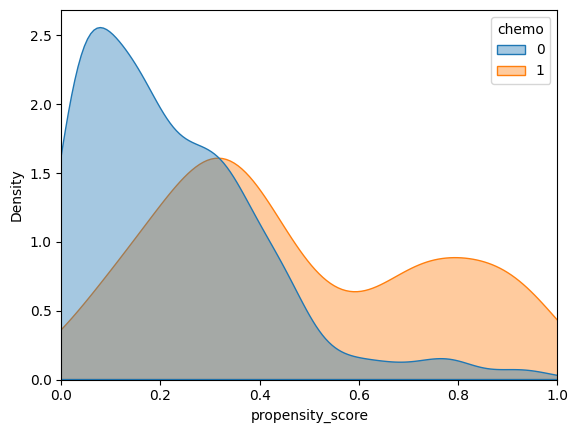

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(
    data=df_combined,
    x="propensity_score",
    hue="chemo",
    common_norm=False,
    fill=True,
    alpha=0.4
)
plt.xlim(0, 1)  
plt.show()

#### 1 to 2 Matching based on propensity scores

In [26]:
from causalml.match import NearestNeighborMatch
psm = NearestNeighborMatch(replace=False, ratio=2, caliper=0.05)
df_matched = psm.match(data=df_combined, treatment_col="chemo", score_cols=["propensity_score"])


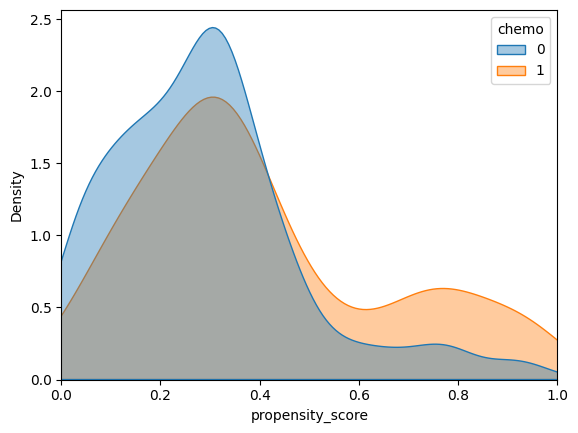

In [27]:
sns.kdeplot(
    data=df_matched,
    x="propensity_score",
    hue="chemo",
    common_norm=False,
    fill=True,
    alpha=0.4
)
plt.xlim(0, 1)  
plt.show()

In [28]:
df_matched.drop(columns = ["propensity_score"], inplace=True)
df_matched.to_csv("../data/matched_cohort.csv", index = False)

#### We could compare covariate distribution before and after matching